# 05. img2col 연산 요약 및 구현 실습

## 학습 목표
1. `img2col`이 왜 Convolution을 빠르게 만드는지 이해한다.
2. 2D 이미지와 다채널 입력에서 `img2col`을 직접 구현한다.
3. `im2col + GEMM` 결과와 naive convolution 결과가 같음을 검증한다.

---

`img2col`은 입력 이미지의 슬라이딩 윈도우를 펼쳐 행렬로 만든 뒤,
합성곱을 **행렬곱(GEMM)** 으로 바꾸는 핵심 아이디어입니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1) img2col 개념 요약

입력 텐서가 `(C, H, W)`, 커널이 `(F, C, KH, KW)`일 때

- 출력 공간 크기:
  - `OH = (H + 2P - KH) // S + 1`
  - `OW = (W + 2P - KW) // S + 1`
- `img2col` 결과 행렬:
  - shape = `(C * KH * KW, OH * OW)`
- 커널 행렬 변환:
  - shape = `(F, C * KH * KW)`
- 최종:
  - `Y_col = W_col @ X_col` → shape `(F, OH*OW)`
  - reshape하면 `(F, OH, OW)`

즉, 합성곱을 대규모 행렬곱으로 치환해 BLAS 최적화를 활용합니다.

In [2]:
# 작은 예제로 직관 확인
x = np.arange(1, 17).reshape(4, 4).astype(np.float32)  # (H=4, W=4)
k = np.array([[1, 0], [0, -1]], dtype=np.float32)      # (KH=2, KW=2)

print("입력 x:\n", x)
print("커널 k:\n", k)

입력 x:
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]
커널 k:
 [[ 1.  0.]
 [ 0. -1.]]


In [3]:
def conv2d_naive(x2d: np.ndarray, k2d: np.ndarray, stride: int = 1, pad: int = 0) -> np.ndarray:
    if pad > 0:
        x2d = np.pad(x2d, ((pad, pad), (pad, pad)), mode="constant")

    H, W = x2d.shape
    KH, KW = k2d.shape
    OH = (H - KH) // stride + 1
    OW = (W - KW) // stride + 1

    out = np.zeros((OH, OW), dtype=np.float32)
    for i in range(OH):
        for j in range(OW):
            patch = x2d[i*stride:i*stride+KH, j*stride:j*stride+KW]
            out[i, j] = np.sum(patch * k2d)
    return out


def img2col_2d(x2d: np.ndarray, KH: int, KW: int, stride: int = 1, pad: int = 0) -> np.ndarray:
    if pad > 0:
        x2d = np.pad(x2d, ((pad, pad), (pad, pad)), mode="constant")

    H, W = x2d.shape
    OH = (H - KH) // stride + 1
    OW = (W - KW) // stride + 1

    cols = []
    for i in range(OH):
        for j in range(OW):
            patch = x2d[i*stride:i*stride+KH, j*stride:j*stride+KW]
            cols.append(patch.reshape(-1))

    # shape: (KH*KW, OH*OW)
    return np.stack(cols, axis=1).astype(np.float32)


# naive conv
y_naive = conv2d_naive(x, k, stride=1, pad=0)

# img2col + matmul
X_col = img2col_2d(x, KH=2, KW=2, stride=1, pad=0)
K_col = k.reshape(1, -1)  # (1, KH*KW)
Y_col = K_col @ X_col     # (1, OH*OW)
y_col = Y_col.reshape(y_naive.shape)

print("X_col shape:", X_col.shape)
print("K_col shape:", K_col.shape)
print("naive 결과:\n", y_naive)
print("img2col 결과:\n", y_col)
print("동일 여부:", np.allclose(y_naive, y_col))

X_col shape: (4, 9)
K_col shape: (1, 4)
naive 결과:
 [[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]
img2col 결과:
 [[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]
동일 여부: True


,patch_0,patch_1,patch_2,patch_3,patch_4,patch_5,patch_6,patch_7,patch_8
k_elem_0,1.0,2.0,3.0,5.0,6.0,7.0,9.0,10.0,11.0
k_elem_1,2.0,3.0,4.0,6.0,7.0,8.0,10.0,11.0,12.0
k_elem_2,5.0,6.0,7.0,9.0,10.0,11.0,13.0,14.0,15.0
k_elem_3,6.0,7.0,8.0,10.0,11.0,12.0,14.0,15.0,16.0


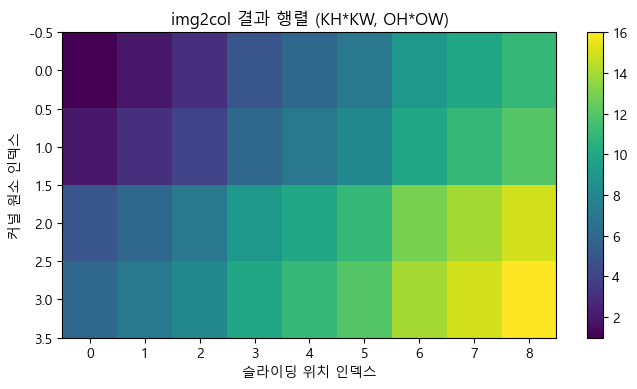

In [4]:
# img2col 행렬을 표로 확인
col_names = [f"patch_{i}" for i in range(X_col.shape[1])]
row_names = [f"k_elem_{i}" for i in range(X_col.shape[0])]

display(pd.DataFrame(X_col, index=row_names, columns=col_names))

plt.figure(figsize=(7, 4))
plt.imshow(X_col, cmap="viridis", aspect="auto")
plt.title("img2col 결과 행렬 (KH*KW, OH*OW)")
plt.xlabel("슬라이딩 위치 인덱스")
plt.ylabel("커널 원소 인덱스")
plt.colorbar()
plt.tight_layout()
plt.show()

## 2) 다채널 입력(C,H,W) img2col 구현

실제 CNN 입력은 보통 다채널입니다.
예: RGB 이미지 `C=3`.

아래 구현은 `(C,H,W)` 입력과 `(F,C,KH,KW)` 커널을 처리합니다.

In [5]:
def img2col_chw(x: np.ndarray, KH: int, KW: int, stride: int = 1, pad: int = 0) -> np.ndarray:
    """
    x: (C, H, W)
    return: (C*KH*KW, OH*OW)
    """
    C, H, W = x.shape
    if pad > 0:
        x = np.pad(x, ((0, 0), (pad, pad), (pad, pad)), mode="constant")
        H, W = H + 2*pad, W + 2*pad

    OH = (H - KH) // stride + 1
    OW = (W - KW) // stride + 1

    cols = np.zeros((C * KH * KW, OH * OW), dtype=np.float32)
    col_idx = 0
    for i in range(OH):
        for j in range(OW):
            patch = x[:, i*stride:i*stride+KH, j*stride:j*stride+KW]  # (C,KH,KW)
            cols[:, col_idx] = patch.reshape(-1)
            col_idx += 1
    return cols


def conv2d_multi_naive(x: np.ndarray, w: np.ndarray, stride: int = 1, pad: int = 0) -> np.ndarray:
    """
    x: (C,H,W), w: (F,C,KH,KW)
    return: (F,OH,OW)
    """
    C, H, W = x.shape
    F, Cw, KH, KW = w.shape
    assert C == Cw

    if pad > 0:
        x_pad = np.pad(x, ((0,0),(pad,pad),(pad,pad)), mode="constant")
    else:
        x_pad = x

    _, Hp, Wp = x_pad.shape
    OH = (Hp - KH) // stride + 1
    OW = (Wp - KW) // stride + 1

    out = np.zeros((F, OH, OW), dtype=np.float32)
    for f in range(F):
        for i in range(OH):
            for j in range(OW):
                patch = x_pad[:, i*stride:i*stride+KH, j*stride:j*stride+KW]
                out[f, i, j] = np.sum(patch * w[f])
    return out

In [6]:
# 랜덤 텐서로 검증
rng = np.random.default_rng(0)
C, H, W = 3, 6, 6
F, KH, KW = 4, 3, 3
stride, pad = 1, 1

x3 = rng.normal(0, 1, (C, H, W)).astype(np.float32)
w4 = rng.normal(0, 1, (F, C, KH, KW)).astype(np.float32)

# naive
y_naive_m = conv2d_multi_naive(x3, w4, stride=stride, pad=pad)

# img2col + GEMM
Xc = img2col_chw(x3, KH=KH, KW=KW, stride=stride, pad=pad)     # (C*KH*KW, OH*OW)
Wc = w4.reshape(F, -1)                                           # (F, C*KH*KW)
Yc = Wc @ Xc                                                      # (F, OH*OW)
OH, OW = y_naive_m.shape[1], y_naive_m.shape[2]
y_col_m = Yc.reshape(F, OH, OW)

print("Xc shape:", Xc.shape)
print("Wc shape:", Wc.shape)
print("Yc shape:", Yc.shape)
print("출력 일치 여부:", np.allclose(y_naive_m, y_col_m, atol=1e-5))
print("최대 절대 오차:", np.max(np.abs(y_naive_m - y_col_m)))

Xc shape: (27, 36)
Wc shape: (4, 27)
Yc shape: (4, 36)
출력 일치 여부: True
최대 절대 오차: 1.9073486e-06


## 3) 연산량/메모리 관점 요약

- **장점**
  - Convolution을 GEMM으로 바꿔 고성능 라이브러리 최적화 활용
  - 병렬화/벡터화에 유리
- **단점**
  - `img2col` 행렬 생성으로 메모리 사용량 증가
  - 특히 큰 입력/커널에서 메모리 병목 가능

따라서 실무 프레임워크는 `im2col`, `Winograd`, `FFT`, 직접 커널 최적화를 상황별로 선택합니다.

In [7]:
def estimate_sizes(C, H, W, KH, KW, stride=1, pad=0, dtype_bytes=4):
    OH = (H + 2*pad - KH) // stride + 1
    OW = (W + 2*pad - KW) // stride + 1
    input_elems = C * H * W
    col_elems = (C * KH * KW) * (OH * OW)
    return {
        "OH": OH,
        "OW": OW,
        "input_MB": input_elems * dtype_bytes / (1024**2),
        "img2col_MB": col_elems * dtype_bytes / (1024**2),
        "expansion_x": col_elems / input_elems,
    }

cases = [
    (3, 224, 224, 3, 3),
    (64, 56, 56, 3, 3),
    (128, 28, 28, 3, 3),
]

rows = []
for C, H, W, KH, KW in cases:
    r = estimate_sizes(C, H, W, KH, KW, stride=1, pad=1)
    rows.append({"C": C, "H": H, "W": W, "KH": KH, "KW": KW, **r})

mem_df = pd.DataFrame(rows)
mem_df

,C,H,W,KH,KW,OH,OW,input_MB,img2col_MB,expansion_x
0,3,224,224,3,3,224,224,0.574219,5.167969,9.0
1,64,56,56,3,3,56,56,0.765625,6.890625,9.0
2,128,28,28,3,3,28,28,0.382812,3.445312,9.0


## 4) 실습 과제

1. `stride=2`, `pad=0`으로 바꿔 출력 shape 변화를 확인하세요.
2. `KH=5, KW=5`로 바꿨을 때 `img2col` 메모리 팽창 비율을 비교하세요.
3. `img2col_chw`를 배치 입력 `(N,C,H,W)`로 확장 구현해 보세요.
4. `im2col + GEMM`과 naive 구현의 실행 시간을 `time`으로 비교해 보세요.

---

### 한 줄 정리
`img2col`은 **합성곱을 행렬곱으로 재구성**해 속도를 얻는 대신, **메모리를 더 사용**하는 전략입니다.